# Estrutura — camada trusted (tancagem)

**Objetivo:** documentar a estrutura do parquet unificado, mapear nulos e analisar tancagem por UF.

**Pré-requisito:** `py estudos/tancagem-abastecimento/pipelines/build_trusted.py`

In [21]:
import json
import sys
from pathlib import Path

import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from _paths import (
    REPO_ROOT,
    TRUSTED_DIR,
    TRUSTED_MANIFEST,
    TRUSTED_PARQUET,
)

EXPECTED_COLS = [
    "Data",
    "NomeEmpresarial",
    "Uf",
    "Municipio",
    "Cnpj",
    "CodInstalacao",
    "Segmento",
    "DetalheInstalacao",
    "Tag",
    "TipoDaUnidade",
    "GrupoDeProdutos",
    "TancagemM3",
]
META_COLS = ["_source_file", "_source_year", "_source_period"]

if not TRUSTED_PARQUET.exists():
    raise FileNotFoundError(
        f"Parquet ausente. Execute build_trusted.py. Esperado: {TRUSTED_PARQUET}"
    )

df = pd.read_parquet(TRUSTED_PARQUET)
manifest = json.loads(TRUSTED_MANIFEST.read_text(encoding="utf-8"))

print(f"Repo: {REPO_ROOT}")
print(f"Parquet: {TRUSTED_PARQUET.relative_to(REPO_ROOT)}")
print(f"Linhas: {len(df):,} | Colunas: {len(df.columns)}")
print(f"Gerado em (manifest): {manifest.get('gerado_em')}")
print(f"Arquivos fonte: {manifest.get('arquivos')}")

Repo: C:\Users\Pichau\Documents\Projetos\ANP\anp-fuel-analytics
Parquet: data\trusted\tancagem-abastecimento\tancagem.parquet
Linhas: 479,054 | Colunas: 15
Gerado em (manifest): 2026-05-23T00:35:30.109163+00:00
Arquivos fonte: 36


## 1. Estrutura do dataset

In [22]:
print("Colunas (ordem no parquet):")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2}. {c} ({df[c].dtype})")

missing_expected = set(EXPECTED_COLS) - set(df.columns)
extra_cols = set(df.columns) - set(EXPECTED_COLS + META_COLS)
print(f"\nColunas esperadas ausentes: {missing_expected or 'nenhuma'}")
print(f"Colunas extras: {extra_cols or 'nenhuma'}")

Colunas (ordem no parquet):
   1. Data (object)
   2. NomeEmpresarial (str)
   3. Uf (str)
   4. Municipio (str)
   5. Cnpj (str)
   6. CodInstalacao (str)
   7. Segmento (str)
   8. DetalheInstalacao (str)
   9. Tag (str)
  10. TipoDaUnidade (str)
  11. GrupoDeProdutos (str)
  12. TancagemM3 (float64)
  13. _source_file (str)
  14. _source_year (str)
  15. _source_period (str)

Colunas esperadas ausentes: nenhuma
Colunas extras: nenhuma


In [23]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 479054 entries, 0 to 479053
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Data               479054 non-null  object 
 1   NomeEmpresarial    479054 non-null  str    
 2   Uf                 479054 non-null  str    
 3   Municipio          479054 non-null  str    
 4   Cnpj               479054 non-null  str    
 5   CodInstalacao      479054 non-null  str    
 6   Segmento           479054 non-null  str    
 7   DetalheInstalacao  479054 non-null  str    
 8   Tag                479054 non-null  str    
 9   TipoDaUnidade      479054 non-null  str    
 10  GrupoDeProdutos    479054 non-null  str    
 11  TancagemM3         479054 non-null  float64
 12  _source_file       479054 non-null  str    
 13  _source_year       479054 non-null  str    
 14  _source_period     479054 non-null  str    
dtypes: float64(1), object(1), str(13)
memory usage: 150.5 MB


In [24]:
display(df.head(3))
df.describe(include="all").T

,Data,NomeEmpresarial,Uf,Municipio,Cnpj,CodInstalacao,Segmento,DetalheInstalacao,Tag,TipoDaUnidade,GrupoDeProdutos,TancagemM3,_source_file,_source_year,_source_period
0,2022-09-01,ADMINISTRADORA DE BENS E INFRAESTRUTURA LTDA,MT,SINOP,10701088000807,1271724,TERMINAL,TERRESTRE,TQ-07 (CONTAMINADOS),TANQUE,OUTROS,55.0,2022/tancagem_terminais_dados_abertos_2022_09_...,2022,tancagem_terminais_dados_abertos_2022_09_01
1,2022-09-01,AMAZONGAS DISTRIB DE GAS LIQUEF DE PETROLEO LTDA,RO,PORTO VELHO,04957650000938,1032928,BASES DO RAMO DE LIQUEFEITOS,EXCLUSIVA,01,ESFERA,GLP,2174.0,2022/tancagem_terminais_dados_abertos_2022_09_...,2022,tancagem_terminais_dados_abertos_2022_09_01
2,2022-09-01,BCAG Brasil China Armazens Gerais S/A,SP,PAULINIA,14498445000239,1257486,TERMINAL,TERRESTRE,RV-2107,TANQUE,OUTROS,40.0,2022/tancagem_terminais_dados_abertos_2022_09_...,2022,tancagem_terminais_dados_abertos_2022_09_01


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Data,479054,33,2023-12-04,41115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NomeEmpresarial,479054,1233,PETROLEO BRASILEIRO S/A,38068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Uf,479054,27,SP,132824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Municipio,479054,814,SANTOS,27552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cnpj,479054,2563,33000167008862,8646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CodInstalacao,479054,1919,1032149,8506,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segmento,479054,11,BASES DO RAMO DE COMBUSTÍVEIS,87681,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DetalheInstalacao,479054,12,EXCLUSIVA,187637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tag,479054,6233,01,13069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TipoDaUnidade,479054,3,TANQUE,431550,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Nulos e preenchimento por coluna

In [25]:
n = len(df)

def empty_string_count(series: pd.Series) -> int:
    if series.dtype != object and not pd.api.types.is_string_dtype(series):
        return 0
    return int(series.fillna("").astype(str).str.strip().eq("").sum())

rows = []
for col in df.columns:
    null_n = int(df[col].isna().sum())
    empty_n = empty_string_count(df[col])
    filled_n = n - null_n
    rows.append(
        {
            "coluna": col,
            "dtype": str(df[col].dtype),
            "nulos": null_n,
            "%_nulos": round(100 * null_n / n, 4),
            "preenchidos": filled_n,
            "%_preenchidos": round(100 * filled_n / n, 4),
            "strings_vazias": empty_n,
            "status": "OK" if null_n == 0 and empty_n == 0 else "revisar",
        }
    )

null_report = pd.DataFrame(rows).set_index("coluna")
null_report

,dtype,nulos,%_nulos,preenchidos,%_preenchidos,strings_vazias,status
coluna,,,,,,,
Data,object,0,0.0,479054,100.0,0,OK
NomeEmpresarial,str,0,0.0,479054,100.0,0,OK
Uf,str,0,0.0,479054,100.0,0,OK
Municipio,str,0,0.0,479054,100.0,0,OK
Cnpj,str,0,0.0,479054,100.0,0,OK
CodInstalacao,str,0,0.0,479054,100.0,0,OK
Segmento,str,0,0.0,479054,100.0,0,OK
DetalheInstalacao,str,0,0.0,479054,100.0,0,OK
Tag,str,0,0.0,479054,100.0,0,OK


In [26]:
biz_cols = EXPECTED_COLS
all_biz_null = df[biz_cols].isna().all(axis=1)
print(f"Linhas com todas as colunas de negócio nulas: {all_biz_null.sum():,}")

if all_biz_null.any():
    display(
        df.loc[all_biz_null, META_COLS]
        .value_counts("_source_file")
        .rename("linhas")
        .to_frame()
    )

Linhas com todas as colunas de negócio nulas: 0


In [27]:
partial_null = df[biz_cols].isna().any(axis=1) & ~all_biz_null
print(f"Linhas com nulo parcial (alguma coluna de negócio): {partial_null.sum():,}")

if partial_null.any():
    per_col = df.loc[partial_null, biz_cols].isna().sum().sort_values(ascending=False)
    print("Nulos por coluna (somente linhas parciais):")
    display(per_col[per_col > 0])

Linhas com nulo parcial (alguma coluna de negócio): 0


## 3. Tancagem por UF

Análises agregadas por estado (UF), comparação ano a ano e evolução temporal.

Cada snapshot corresponde a um `_source_file` (evita dupla contagem quando vários arquivos compartilham a mesma `Data`).

### 3.1 Ranking por volume — último snapshot

Agregação por UF na **data máxima** do recorte:

- **tancagem_m3** — soma de capacidade autorizada
- **cnpj_distintos** — empresas distintas (`Cnpj`)
- **tancagem_por_cnpj** — tancagem média por empresa (m³ / CNPJ)

In [28]:
import matplotlib.pyplot as plt

%matplotlib inline

valid = df.dropna(subset=["Uf", "Cnpj", "TancagemM3", "GrupoDeProdutos"]).copy()

latest_date = valid["Data"].max()
latest_date_label = pd.Timestamp(latest_date).date()
snap_latest = valid[valid["Data"] == latest_date]

print(f"Último snapshot (Data): {latest_date_label}")
print(f"Arquivos fonte nessa data: {snap_latest['_source_file'].nunique()}")
print(snap_latest["_source_file"].unique())

ranking_uf = (
    snap_latest.groupby("Uf", as_index=False)
    .agg(
        tancagem_m3=("TancagemM3", "sum"),
        cnpj_distintos=("Cnpj", "nunique"),
    )
    .sort_values("tancagem_m3", ascending=False)
    .reset_index(drop=True)
)
ranking_uf.insert(0, "rank", range(1, len(ranking_uf) + 1))
ranking_uf["tancagem_mil_m3"] = (ranking_uf["tancagem_m3"] / 1_000).round(1)
ranking_uf["tancagem_por_cnpj"] = (ranking_uf["tancagem_m3"] / ranking_uf["cnpj_distintos"]).round(1)

display(
    ranking_uf[
        [
            "rank",
            "Uf",
            "tancagem_m3",
            "tancagem_mil_m3",
            "cnpj_distintos",
            "tancagem_por_cnpj",
        ]
    ]
)

Último snapshot (Data): 2026-04-30
Arquivos fonte nessa data: 1
<ArrowStringArray>
['2026/abril.csv']
Length: 1, dtype: str


,rank,Uf,tancagem_m3,tancagem_mil_m3,cnpj_distintos,tancagem_por_cnpj
0,1,SP,23782183.0,23782.2,385,61771.9
1,2,RJ,6105232.0,6105.2,56,109022.0
2,3,PR,4216981.0,4217.0,184,22918.4
3,4,MG,3718091.0,3718.1,130,28600.7
4,5,GO,3391847.0,3391.8,104,32613.9
5,6,RS,3198184.0,3198.2,157,20370.6
6,7,BA,3108931.0,3108.9,73,42588.1
7,8,PE,2639997.0,2640.0,32,82499.9
8,9,MT,1892124.0,1892.1,148,12784.6
9,10,MS,1691862.0,1691.9,80,21148.3


### 3.2 Ranking YoY — maior aumento de tancagem por UF

Compara o **último snapshot** com o snapshot cuja `Data` está mais próxima de **12 meses antes** (mesmo critério de agregação por `_source_file`).

- **var_m3** / **var_mil_m3** — diferença absoluta (m³ / mil m³); **ranking** por mil m³
- **var_pct** — variação percentual (exibida entre parênteses ao lado de mil m³)

Snapshot atual: 2026-04-30 (2026/abril.csv)
Snapshot referência (~1 ano): 2025-05-09 (2025/marco.csv)
Distância ao alvo de 12 meses: 9 dias

Top aumentos absolutos (m³) — ano contra ano


,rank_aumento_m3,Uf,tancagem_m3_ref,tancagem_m3_atual,var_m3,var_mil_m3,var_pct
0,1,SP,23520113.0,23782183.0,262070.0,262.1,1.114238
1,2,MT,1763628.0,1892124.0,128496.0,128.5,7.285890
2,3,MA,836102.0,955865.0,119763.0,119.8,14.323970
3,4,CE,291252.0,408004.0,116752.0,116.8,40.086248
4,5,PE,2544188.0,2639997.0,95809.0,95.8,3.765799
5,6,GO,3304228.0,3391847.0,87619.0,87.6,2.651724
6,7,MS,1620083.0,1691862.0,71779.0,71.8,4.430575
7,8,PA,827188.0,895624.0,68436.0,68.4,8.273331
8,9,BA,3063529.0,3108931.0,45402.0,45.4,1.482016
9,10,MG,3678931.0,3718091.0,39160.0,39.2,1.064440



Top aumentos percentuais (%) — entre UFs com tancagem de referência > 0


,rank_aumento_pct,Uf,tancagem_m3_ref,tancagem_m3_atual,var_m3,var_pct
0,1,CE,291252.0,408004.0,116752.0,40.086248
1,2,MA,836102.0,955865.0,119763.0,14.323970
2,3,PA,827188.0,895624.0,68436.0,8.273331
3,4,MT,1763628.0,1892124.0,128496.0,7.285890
4,5,MS,1620083.0,1691862.0,71779.0,4.430575
5,6,PE,2544188.0,2639997.0,95809.0,3.765799
6,7,GO,3304228.0,3391847.0,87619.0,2.651724
7,8,BA,3063529.0,3108931.0,45402.0,1.482016
8,9,PI,61563.0,62463.0,900.0,1.461917
9,10,SP,23520113.0,23782183.0,262070.0,1.114238


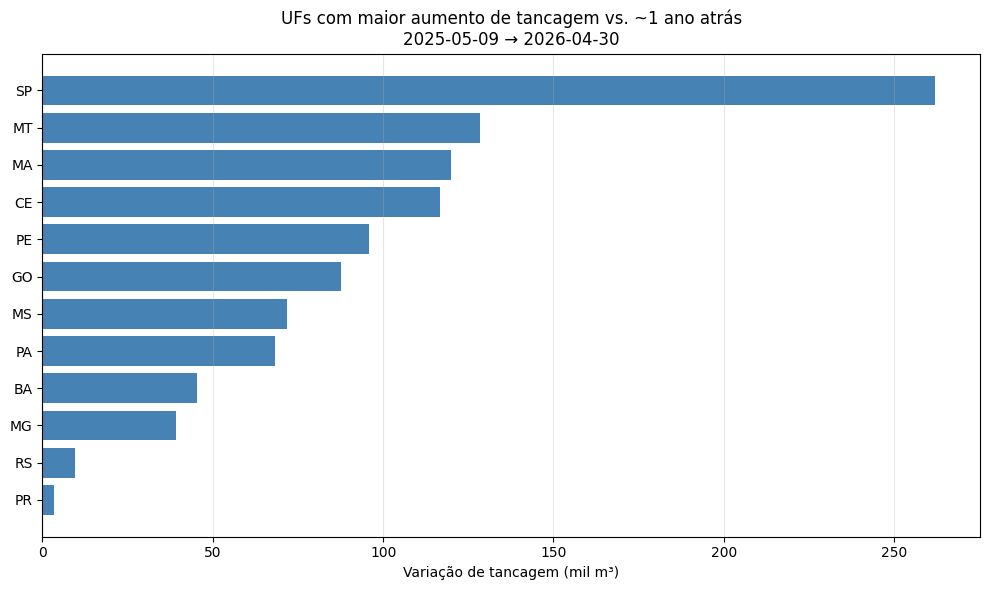

In [29]:
calendario_snapshots = (
    valid.groupby("_source_file", as_index=False)
    .agg(data=("Data", "max"))
    .sort_values("data")
    .reset_index(drop=True)
)

data_atual = calendario_snapshots["data"].max()
arquivo_atual = calendario_snapshots.loc[
    calendario_snapshots["data"] == data_atual, "_source_file"
].iloc[-1]

data_ref_alvo = pd.Timestamp(data_atual) - pd.DateOffset(years=1)
calendario_snapshots["distancia_dias"] = (
    calendario_snapshots["data"].map(pd.Timestamp) - data_ref_alvo
).abs().dt.days

idx_ref = calendario_snapshots["distancia_dias"].idxmin()
data_ref = calendario_snapshots.loc[idx_ref, "data"]
arquivo_ref = calendario_snapshots.loc[idx_ref, "_source_file"]

print(f"Snapshot atual: {pd.Timestamp(data_atual).date()} ({arquivo_atual})")
print(f"Snapshot referência (~1 ano): {pd.Timestamp(data_ref).date()} ({arquivo_ref})")
print(
    f"Distância ao alvo de 12 meses: {calendario_snapshots.loc[idx_ref, 'distancia_dias']} dias"
)


def tancagem_por_uf_no_arquivo(arquivo: str) -> pd.DataFrame:
    return (
        valid.loc[valid["_source_file"] == arquivo]
        .groupby("Uf", as_index=False)["TancagemM3"]
        .sum()
        .rename(columns={"TancagemM3": "tancagem_m3"})
    )


ranking_yoy = (
    tancagem_por_uf_no_arquivo(arquivo_atual)
    .merge(
        tancagem_por_uf_no_arquivo(arquivo_ref),
        on="Uf",
        how="outer",
        suffixes=("_atual", "_ref"),
    )
    .fillna(0)
)
ranking_yoy["var_m3"] = ranking_yoy["tancagem_m3_atual"] - ranking_yoy["tancagem_m3_ref"]
ranking_yoy["var_pct"] = (
    ranking_yoy["var_m3"] / ranking_yoy["tancagem_m3_ref"] * 100
).where(ranking_yoy["tancagem_m3_ref"] > 0)
ranking_yoy["var_mil_m3"] = (ranking_yoy["var_m3"] / 1_000).round(1)


def fmt_mil_m3_com_pct(mil: float, pct: float) -> str:
    if pd.isna(pct):
        return f"{mil:.1f}"
    sinal = "+" if pct >= 0 else ""
    return f"{mil:.1f} ({sinal}{pct:.1f}%)"


ranking_yoy_abs = ranking_yoy.sort_values("var_m3", ascending=False).reset_index(drop=True)
ranking_yoy_abs.insert(0, "rank_aumento_m3", range(1, len(ranking_yoy_abs) + 1))
ranking_yoy_abs["var_mil_m3_fmt"] = ranking_yoy_abs.apply(
    lambda r: fmt_mil_m3_com_pct(r["var_mil_m3"], r["var_pct"]), axis=1
)

ranking_yoy_pct = (
    ranking_yoy.dropna(subset=["var_pct"])
    .sort_values("var_pct", ascending=False)
    .reset_index(drop=True)
)
ranking_yoy_pct.insert(0, "rank_aumento_pct", range(1, len(ranking_yoy_pct) + 1))

print("\nTop aumentos absolutos (mil m³) — ranking por variação em m³; % entre parênteses")
display(
    ranking_yoy_abs[
        [
            "rank_aumento_m3",
            "Uf",
            "tancagem_m3_ref",
            "tancagem_m3_atual",
            "var_m3",
            "var_mil_m3_fmt",
        ]
    ]
    .rename(columns={"var_mil_m3_fmt": "var_mil_m3 (%)"})
    .head(15)
)

print("\nTop aumentos percentuais (%) — entre UFs com tancagem de referência > 0")
display(
    ranking_yoy_pct[
        [
            "rank_aumento_pct",
            "Uf",
            "tancagem_m3_ref",
            "tancagem_m3_atual",
            "var_m3",
            "var_pct",
        ]
    ].head(15)
)

top_plot = ranking_yoy_abs.head(12).sort_values("var_mil_m3")
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_plot["Uf"], top_plot["var_mil_m3"], color="steelblue")
for bar, label in zip(bars, top_plot["var_mil_m3_fmt"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {label}",
        va="center",
        ha="left",
        fontsize=9,
    )
ax.set_xlabel("Variação de tancagem (mil m³); % entre parênteses")
ax.set_title(
    "UFs com maior aumento de tancagem vs. ~1 ano atrás\n"
    f"{pd.Timestamp(data_ref).date()} → {pd.Timestamp(data_atual).date()}"
)
ax.axvline(0, color="gray", linewidth=0.8)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.3 Evolução temporal por UF

Série de tancagem (m³) por estado, um gráfico por UF, ordenados pelo ranking de volume no último snapshot.

Evolução da tancagem — SP (36 snapshots)


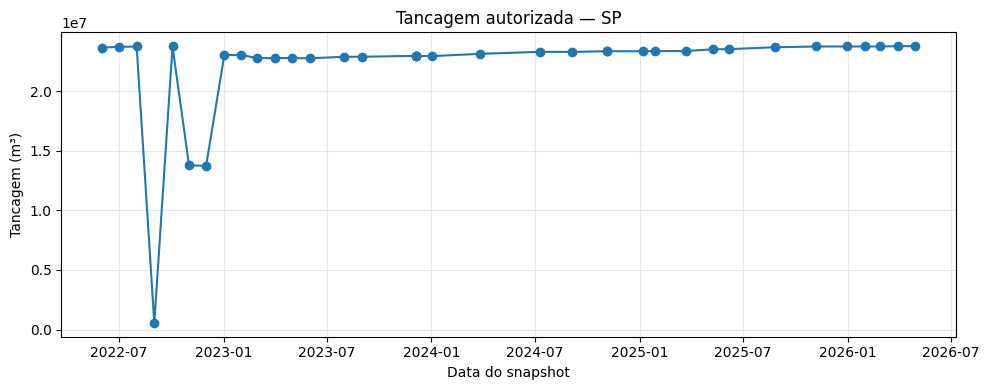

Evolução da tancagem — RJ (36 snapshots)


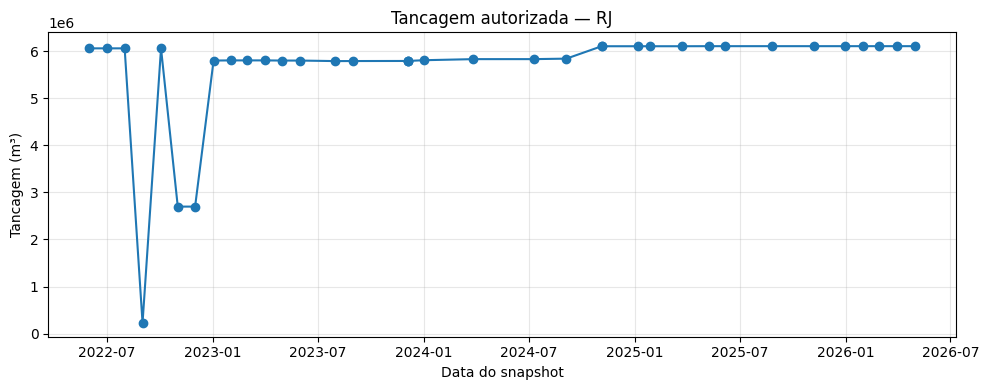

Evolução da tancagem — PR (36 snapshots)


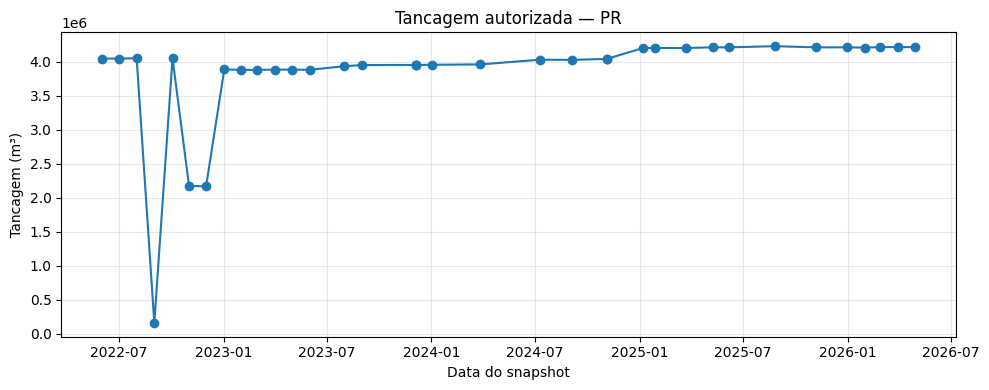

Evolução da tancagem — MG (36 snapshots)


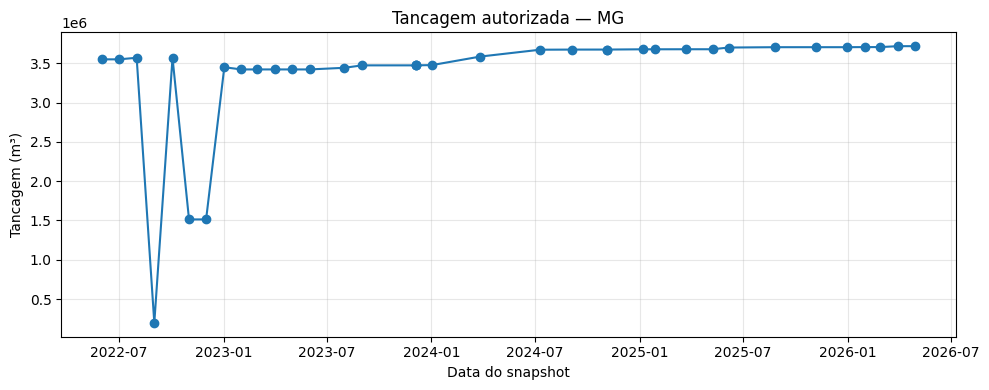

Evolução da tancagem — GO (36 snapshots)


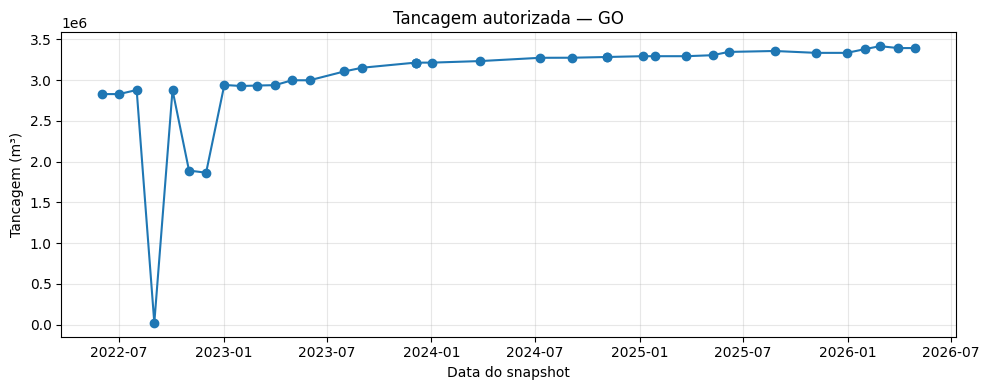

Evolução da tancagem — RS (36 snapshots)


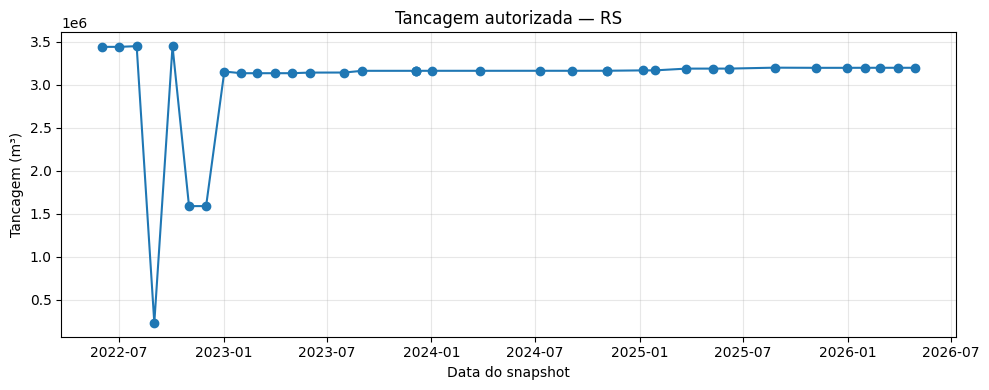

Evolução da tancagem — BA (36 snapshots)


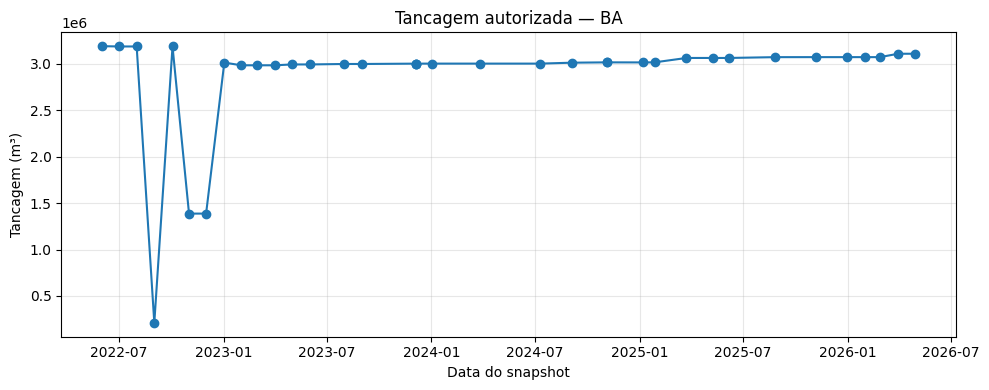

Evolução da tancagem — PE (36 snapshots)


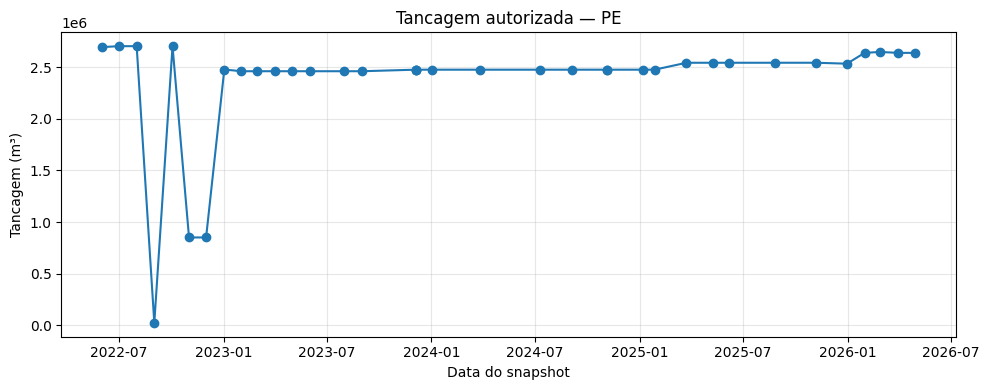

Evolução da tancagem — MT (36 snapshots)


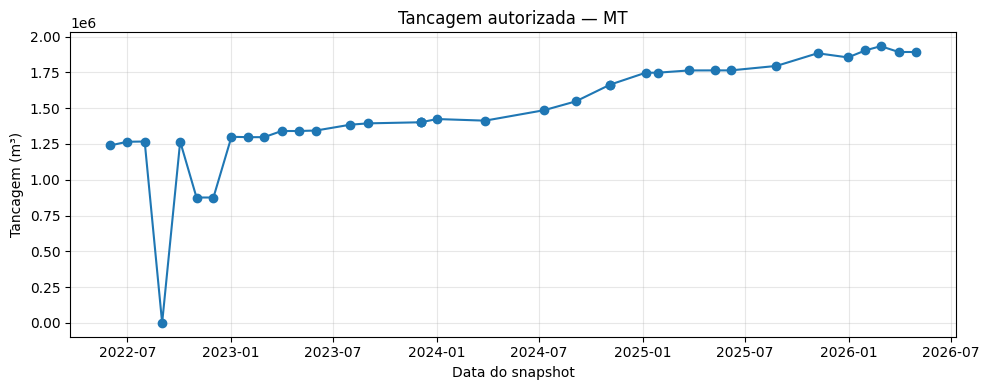

Evolução da tancagem — MS (35 snapshots)


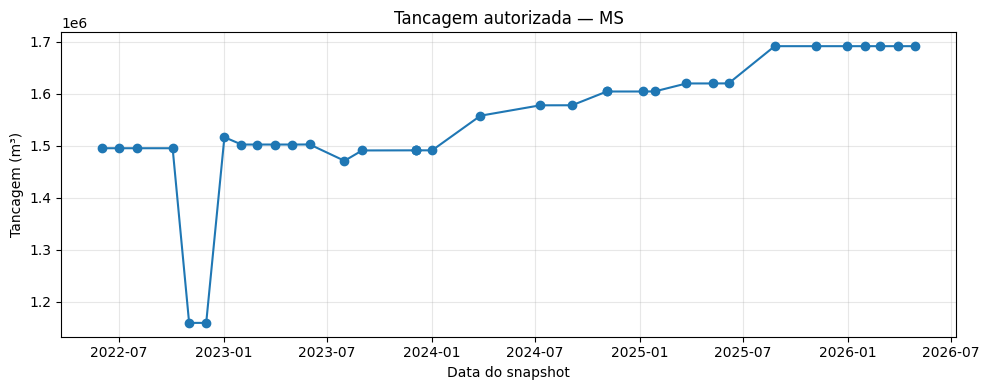

Evolução da tancagem — MA (35 snapshots)


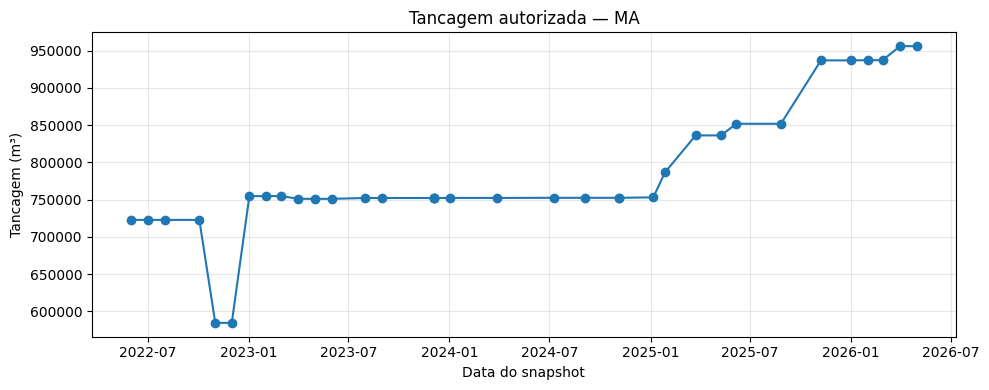

Evolução da tancagem — PA (36 snapshots)


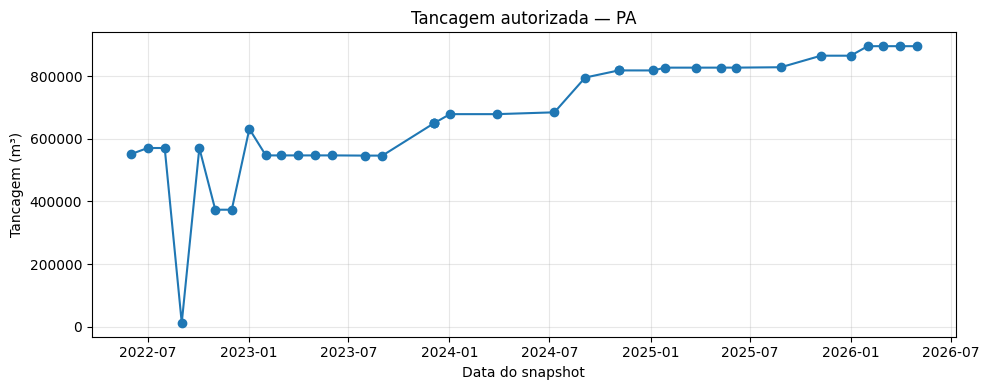

Evolução da tancagem — AM (36 snapshots)


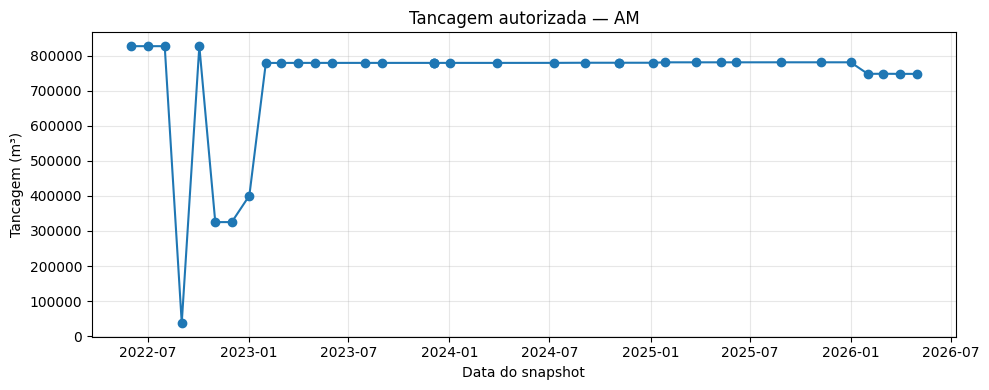

Evolução da tancagem — SC (36 snapshots)


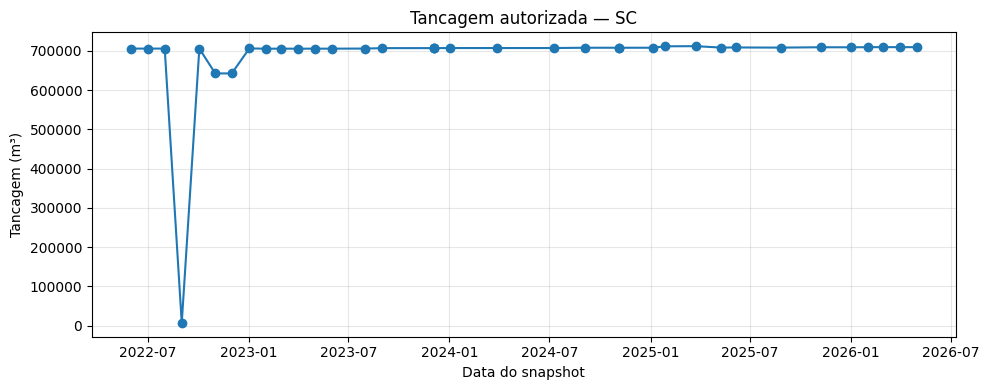

Evolução da tancagem — ES (35 snapshots)


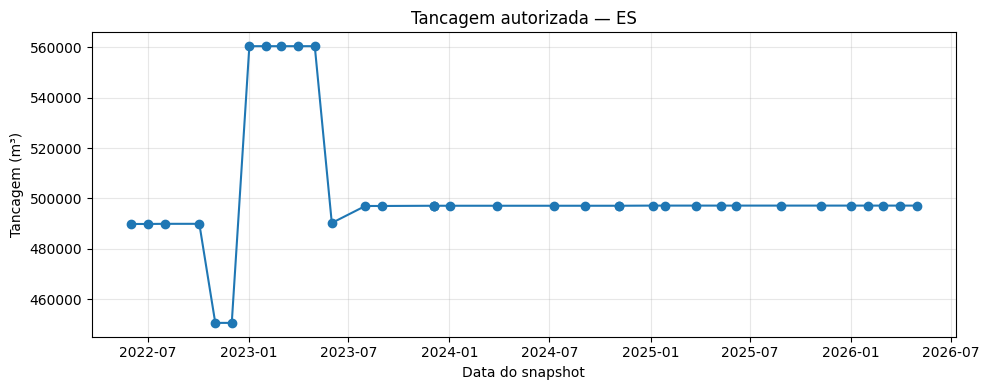

Evolução da tancagem — AL (35 snapshots)


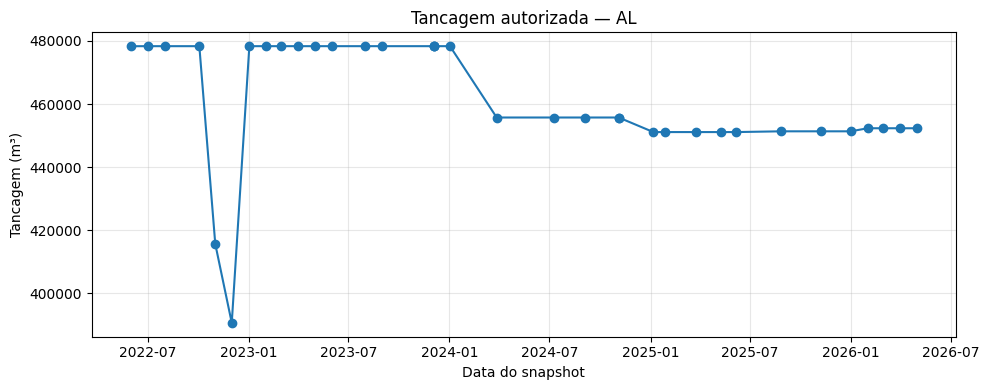

Evolução da tancagem — CE (36 snapshots)


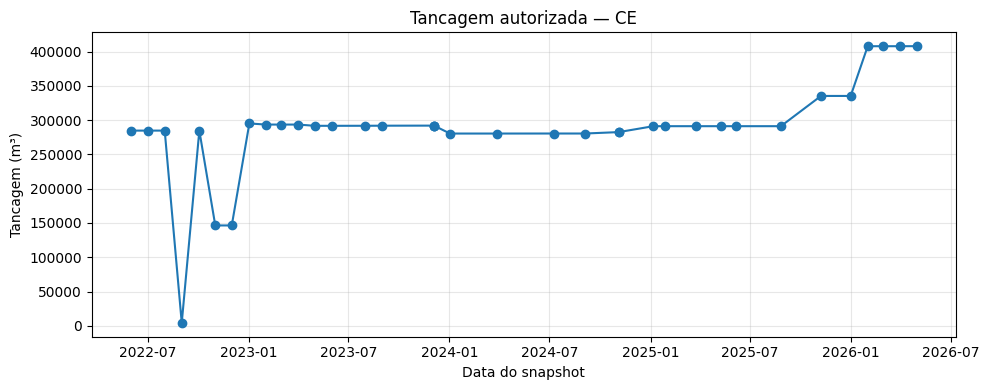

Evolução da tancagem — RN (35 snapshots)


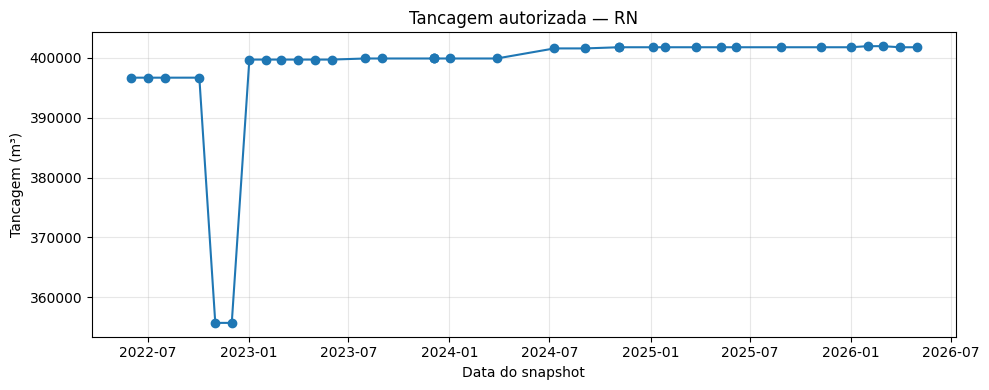

Evolução da tancagem — PB (35 snapshots)


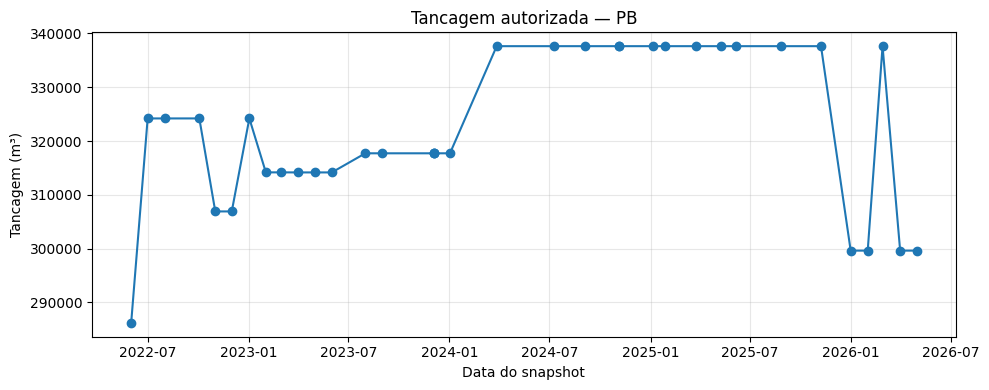

Evolução da tancagem — SE (35 snapshots)


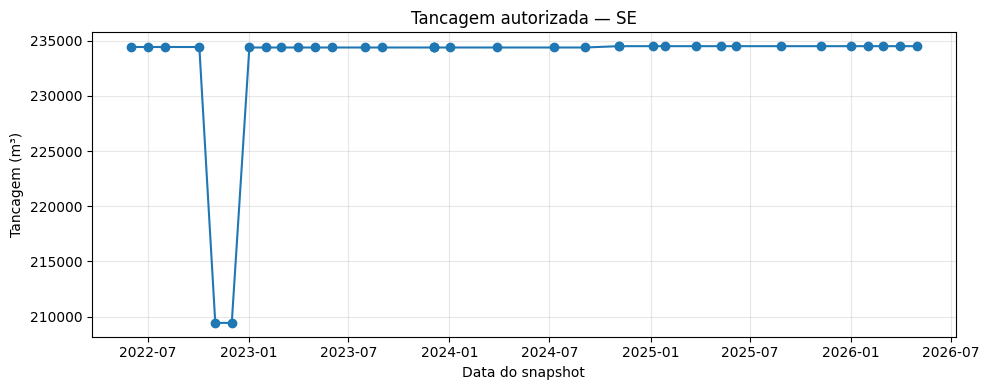

Evolução da tancagem — TO (35 snapshots)


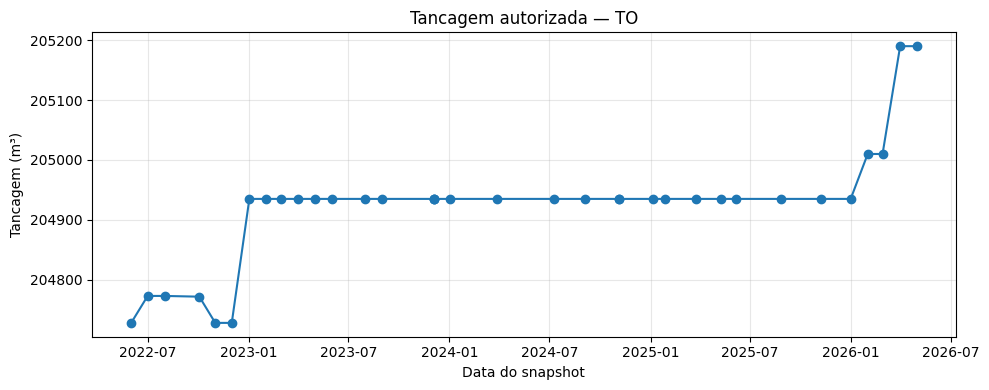

Evolução da tancagem — DF (36 snapshots)


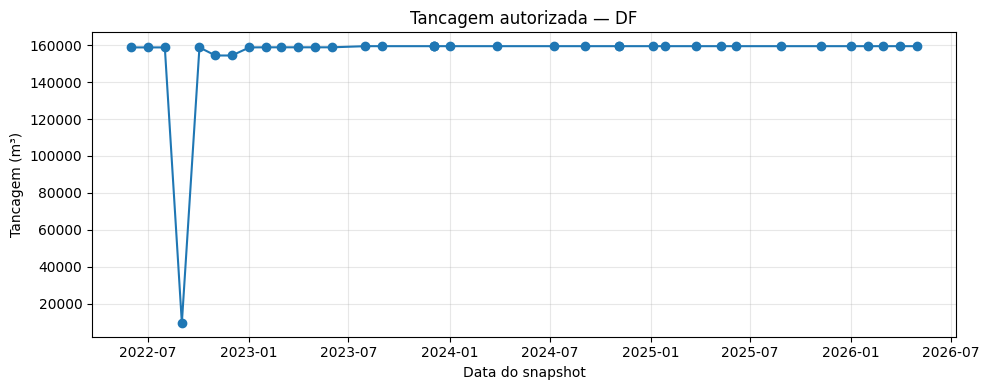

Evolução da tancagem — RO (36 snapshots)


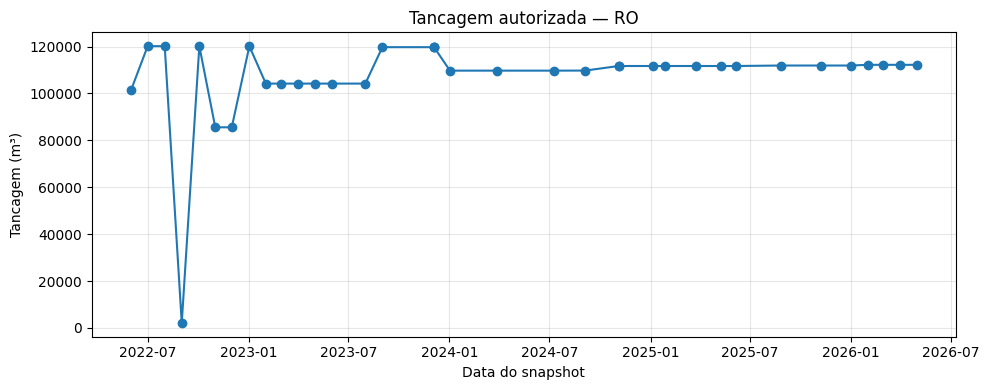

Evolução da tancagem — PI (35 snapshots)


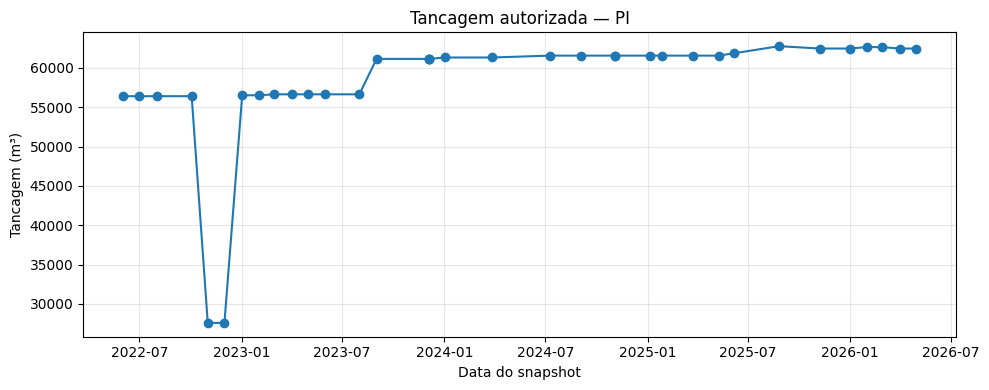

Evolução da tancagem — AC (35 snapshots)


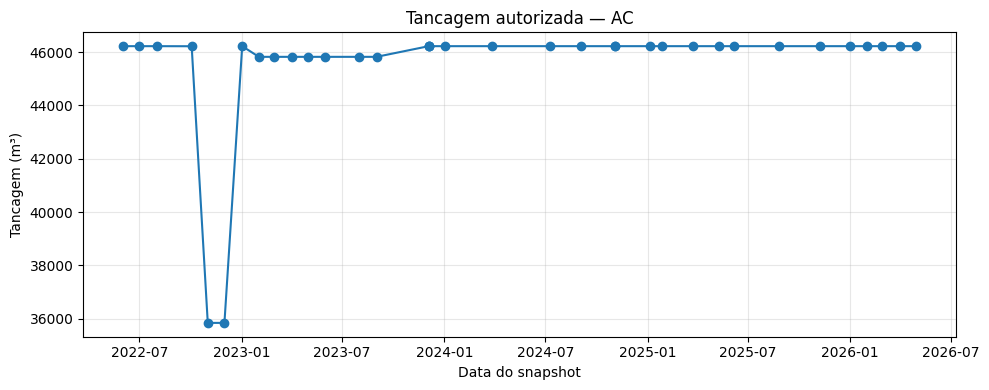

Evolução da tancagem — AP (35 snapshots)


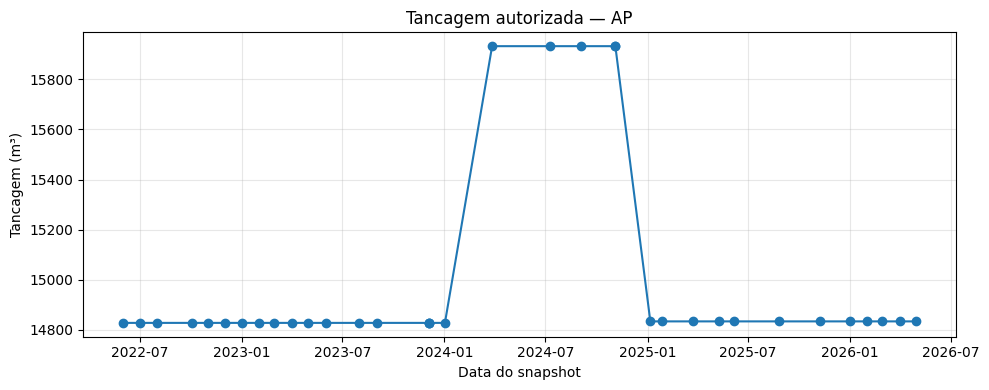

Evolução da tancagem — RR (35 snapshots)


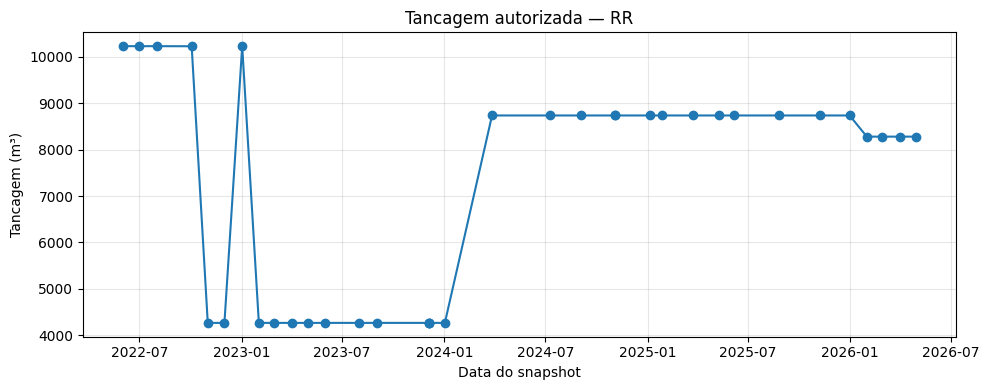

In [30]:
def serie_tancagem_por_snapshot(mask: pd.Series) -> pd.DataFrame:
    """Soma TancagemM3 por arquivo-fonte (1 ponto por snapshot)."""
    ev = (
        valid.loc[mask]
        .groupby("_source_file", as_index=False)
        .agg(
            data=("Data", "max"),
            tancagem_m3=("TancagemM3", "sum"),
        )
        .sort_values("data")
        .reset_index(drop=True)
    )
    ev["tancagem_mil_m3"] = (ev["tancagem_m3"] / 1_000).round(1)
    ev["var_pct_snapshot_anterior"] = ev["tancagem_m3"].pct_change() * 100
    return ev


def plot_evolucao_tancagem(ev: pd.DataFrame, titulo: str) -> None:
    ax = ev.plot(
        x="data",
        y="tancagem_m3",
        kind="line",
        marker="o",
        figsize=(10, 4),
        legend=False,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Data do snapshot")
    ax.set_ylabel("Tancagem (m³)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


ufs_evolucao = ranking_uf["Uf"].tolist()

for uf in ufs_evolucao:
    ev_uf = serie_tancagem_por_snapshot(valid["Uf"] == uf)
    print(f"Evolução da tancagem — {uf} ({len(ev_uf)} snapshots)")
    plot_evolucao_tancagem(ev_uf, f"Tancagem autorizada — {uf}")

### 3.4 Evolução temporal por `DetalheInstalacao`

Soma nacional de `TancagemM3` por snapshot, uma série por valor de `DetalheInstalacao`.

Evolução da tancagem — DetalheInstalacao=COMPARTILHADA (35 snapshots)


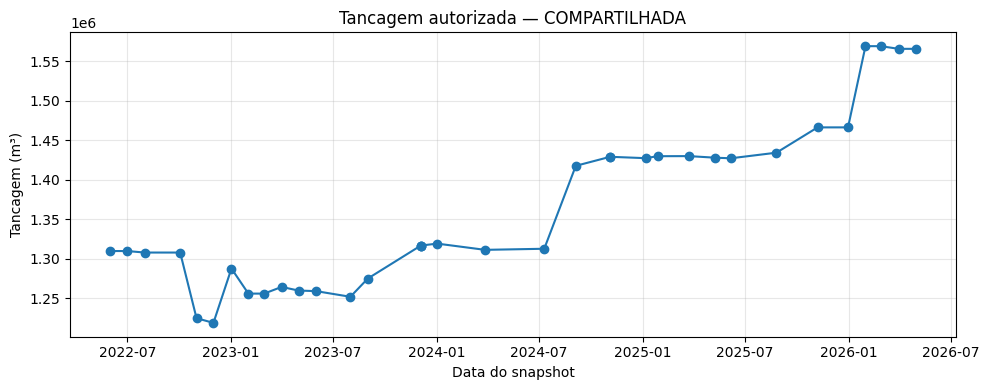

Evolução da tancagem — DetalheInstalacao=EXCLUSIVA (36 snapshots)


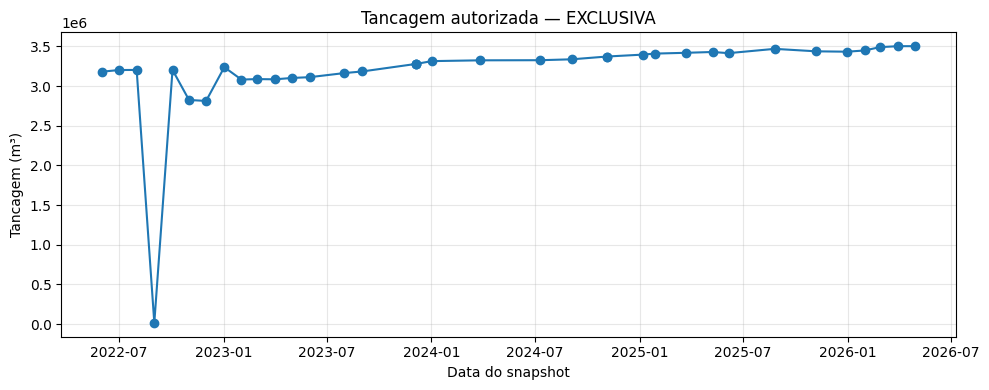

Evolução da tancagem — DetalheInstalacao=FLUVIAL (36 snapshots)


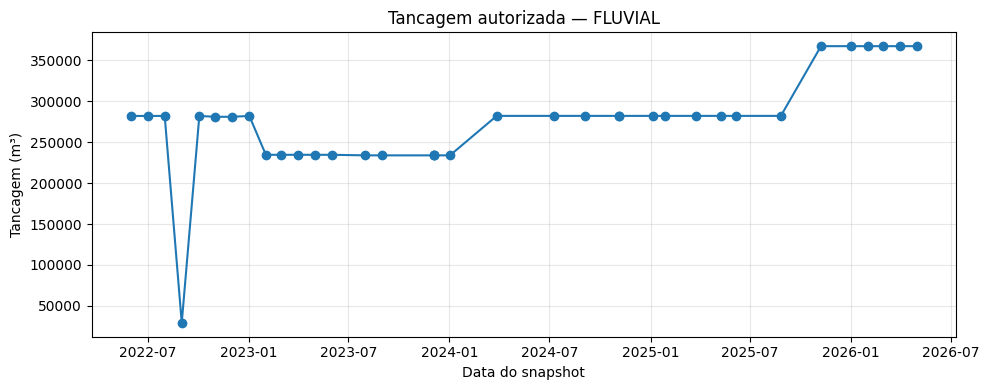

Evolução da tancagem — DetalheInstalacao=LACUSTRE (35 snapshots)


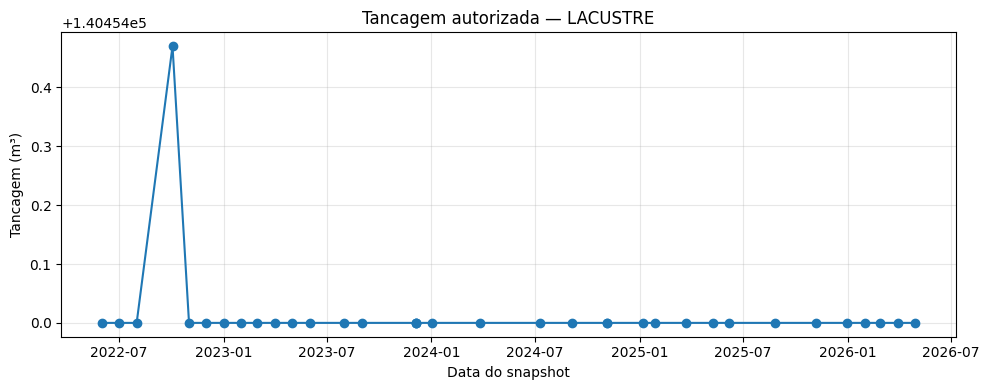

Evolução da tancagem — DetalheInstalacao=MARÍTIMO (35 snapshots)


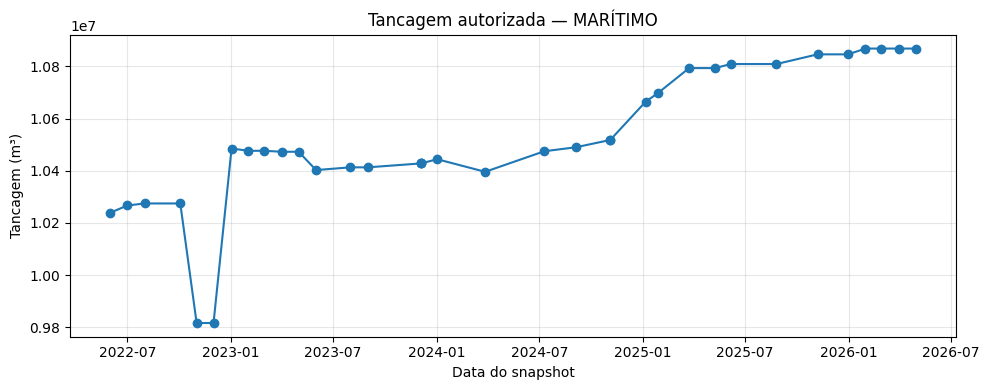

Evolução da tancagem — DetalheInstalacao=PLANTA DE CPQ (32 snapshots)


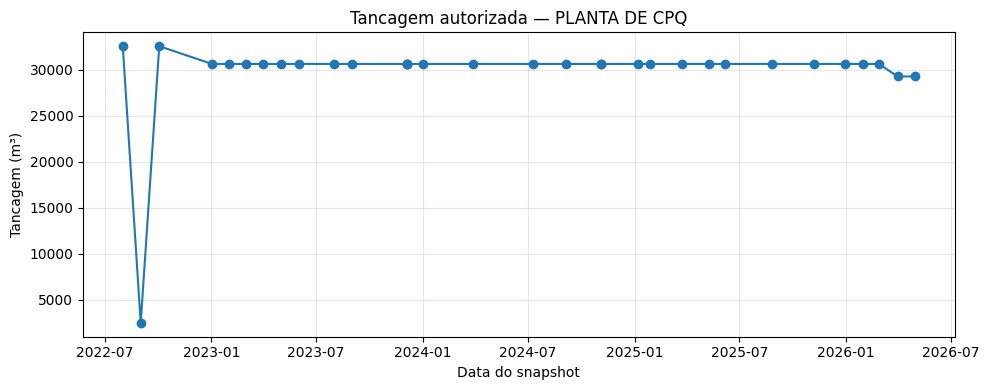

Evolução da tancagem — DetalheInstalacao=PLANTA DE FORMULADOR (15 snapshots)


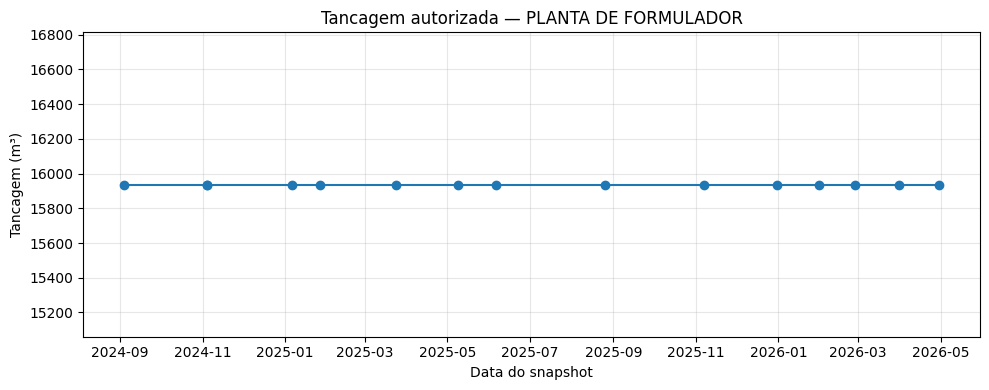

Evolução da tancagem — DetalheInstalacao=PLANTA DE PRODUCAO DE ETANOL (35 snapshots)


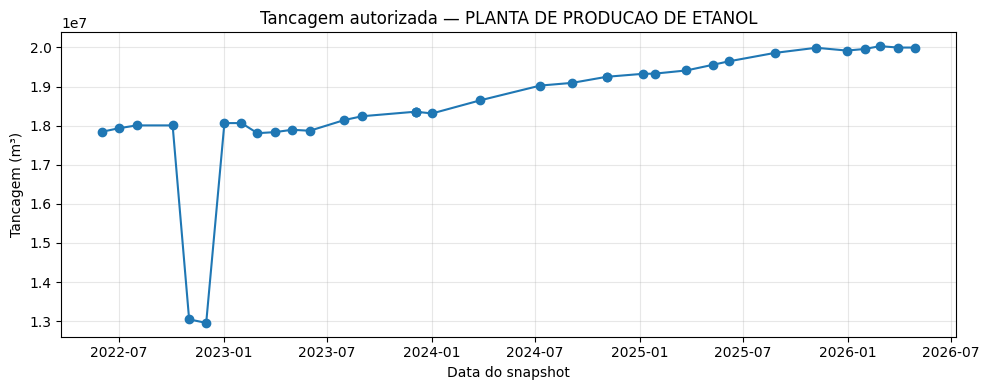

Evolução da tancagem — DetalheInstalacao=PLANTA DE PRODUÇÃO DE BIODIESEL (35 snapshots)


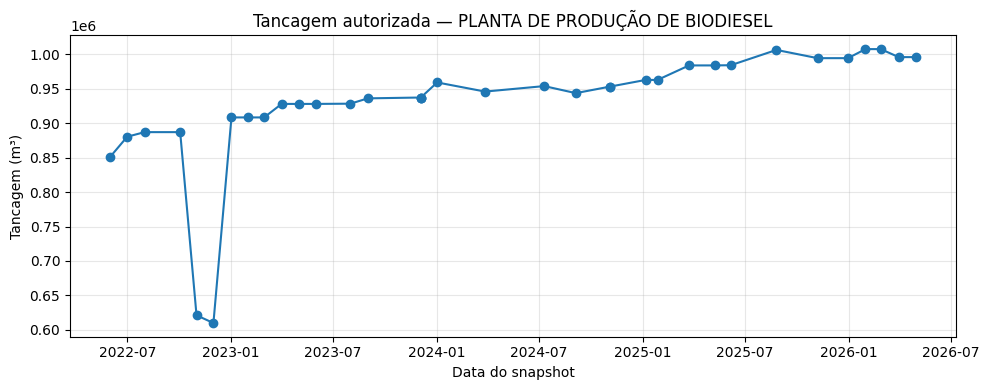

Evolução da tancagem — DetalheInstalacao=PÓLO DE PROCESSAMENTO DE GÁS NATURAL (35 snapshots)


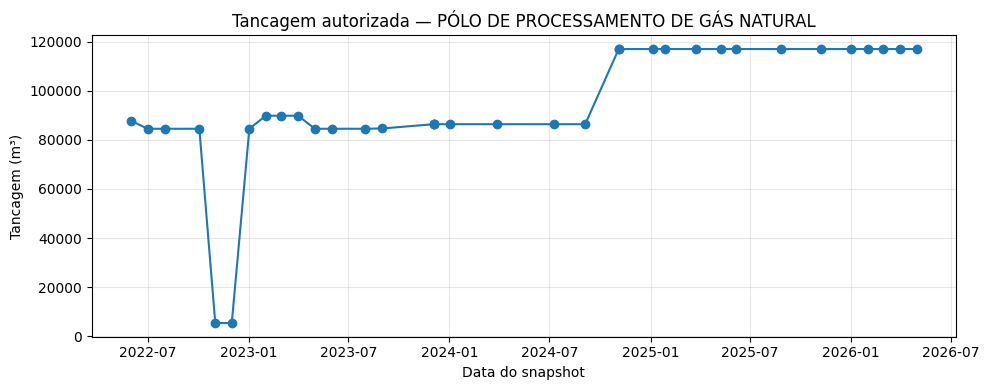

Evolução da tancagem — DetalheInstalacao=REFINARIA (36 snapshots)


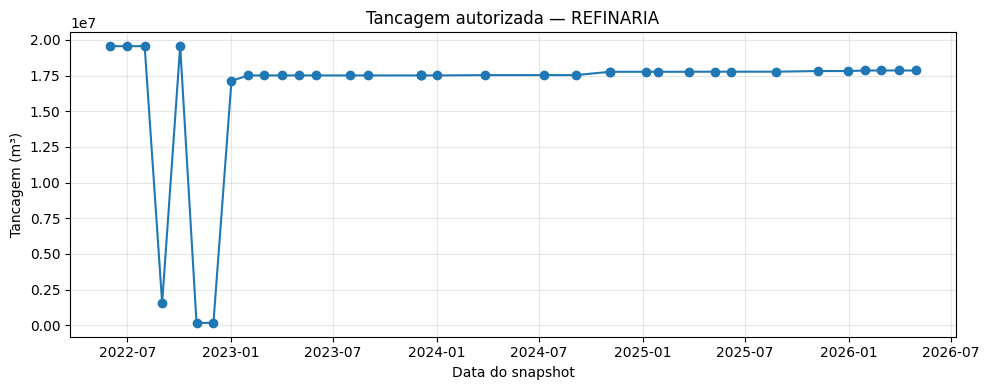

Evolução da tancagem — DetalheInstalacao=TERRESTRE (36 snapshots)


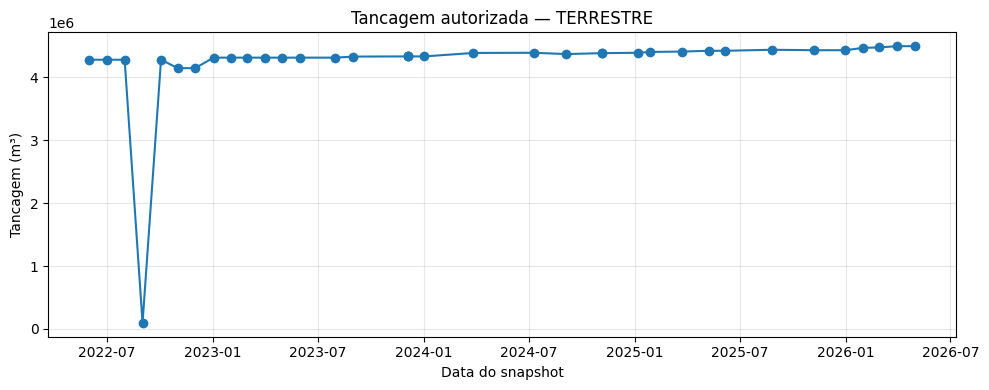

In [31]:
detalhes = sorted(valid["DetalheInstalacao"].dropna().unique())

for detalhe in detalhes:
    ev_detalhe = serie_tancagem_por_snapshot(valid["DetalheInstalacao"] == detalhe)
    print(f"Evolução da tancagem — DetalheInstalacao={detalhe} ({len(ev_detalhe)} snapshots)")
    plot_evolucao_tancagem(ev_detalhe, f"Tancagem autorizada — {detalhe}")

### 3.5 Evolução temporal por `GrupoDeProdutos`

Soma nacional de `TancagemM3` por snapshot, uma série por valor de `GrupoDeProdutos`.

Evolução da tancagem — GrupoDeProdutos=DERIVADOS E BIOCOMBUSTÍVEIS (35 snapshots)


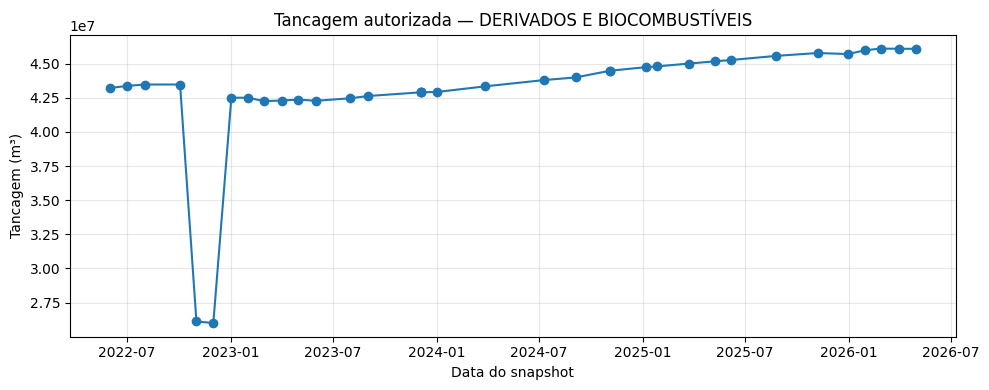

Evolução da tancagem — GrupoDeProdutos=GLP (36 snapshots)


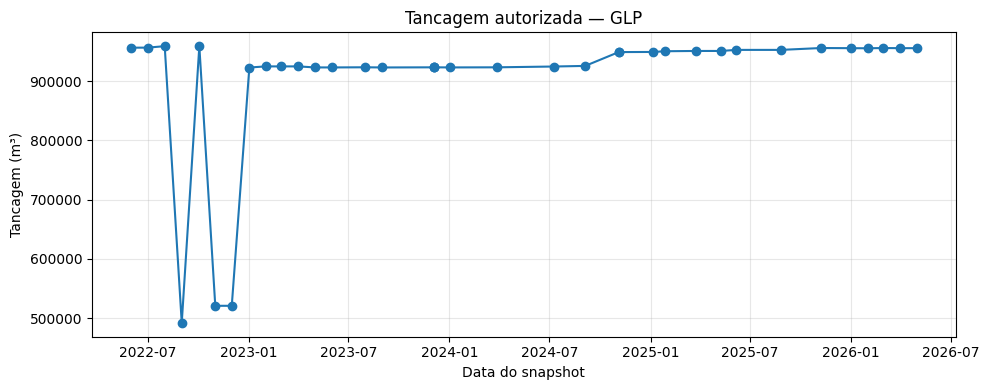

Evolução da tancagem — GrupoDeProdutos=OUTROS (36 snapshots)


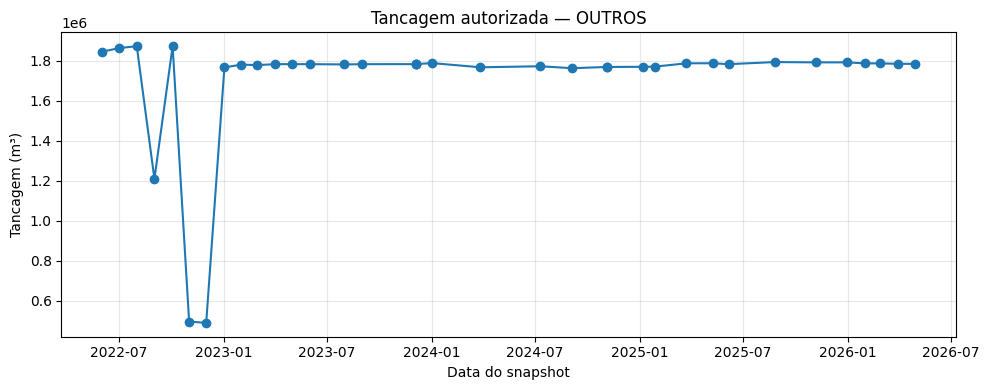

Evolução da tancagem — GrupoDeProdutos=PETRÓLEO (35 snapshots)


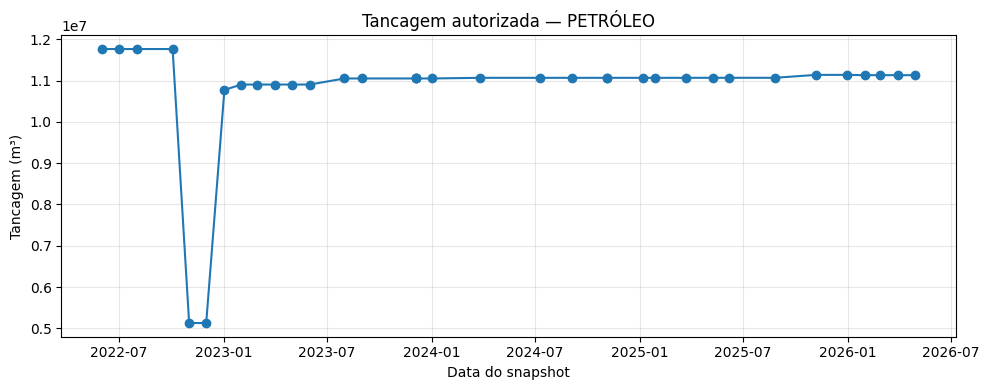

In [32]:
grupos = sorted(valid["GrupoDeProdutos"].dropna().unique())

for grupo in grupos:
    ev_grupo = serie_tancagem_por_snapshot(valid["GrupoDeProdutos"] == grupo)
    print(f"Evolução da tancagem — GrupoDeProdutos={grupo} ({len(ev_grupo)} snapshots)")
    plot_evolucao_tancagem(ev_grupo, f"Tancagem autorizada — {grupo}")

### 3.6 Tancagem por grupo de produto — GO e SP (último snapshot)

Soma de `TancagemM3` por `GrupoDeProdutos`, comparando Goiás e São Paulo no mesmo recorte temporal do ranking por UF.

Uf,GO,SP
GrupoDeProdutos,,
DERIVADOS E BIOCOMBUSTÍVEIS,3307.8,19083.4
GLP,23.6,328.9
OUTROS,60.5,400.2
PETRÓLEO,NaN,3969.6


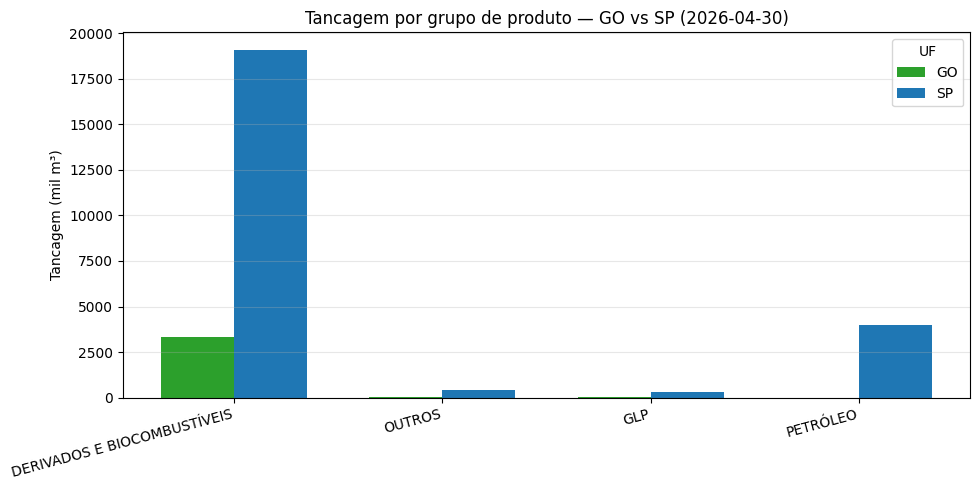

In [33]:
UFS_COMPARAR = ["GO", "SP"]

snap_go_sp = snap_latest[
    snap_latest["Uf"].isin(UFS_COMPARAR) & snap_latest["GrupoDeProdutos"].notna()
].copy()

por_grupo_uf = (
    snap_go_sp.groupby(["Uf", "GrupoDeProdutos"], as_index=False)["TancagemM3"]
    .sum()
    .sort_values("TancagemM3", ascending=False)
)
por_grupo_uf["tancagem_mil_m3"] = (por_grupo_uf["TancagemM3"] / 1_000).round(1)

display(por_grupo_uf.pivot(index="GrupoDeProdutos", columns="Uf", values="tancagem_mil_m3"))

pivot_mil = (
    por_grupo_uf.pivot(index="GrupoDeProdutos", columns="Uf", values="tancagem_mil_m3")
    .reindex(columns=UFS_COMPARAR)
    .fillna(0)
    .sort_values(UFS_COMPARAR, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pivot_mil))
width = 0.35

ax.bar(
    [i - width / 2 for i in x],
    pivot_mil["GO"],
    width=width,
    label="GO",
    color="#2ca02c",
)
ax.bar(
    [i + width / 2 for i in x],
    pivot_mil["SP"],
    width=width,
    label="SP",
    color="#1f77b4",
)

ax.set_xticks(list(x))
ax.set_xticklabels(pivot_mil.index, rotation=15, ha="right")
ax.set_ylabel("Tancagem (mil m³)")
ax.set_title(f"Tancagem por grupo de produto — GO vs SP ({latest_date_label})")
ax.legend(title="UF")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()